In [1]:
import pprint # Pretty print data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # statistical visualisation

#### Import dataset `hse_df_feat.csv`
Target variables
- **dH_hse06:** Formation Enthalpy
- **dG_hse06:** Formation Gibbs free energy

Features
- **r_s:** Wigner-Seitz radius?
- **r_val:** Valence radius
- **r_cov:** Covalent radius
- **e_H:** HOMO Energy
- **e_L:** LUMO Energy
- **AN:** Atomic number
- **IP:** Ionisation potential
- **EA:** Electron affinity
- **EN:** Electronegativity
- **N_val:** Valence electrons
- **N_unf:** Unfilled electrons
- **max_OS:** Maximum oxidation state
- **stdev_OS:** Standard deviation of oxidation states

In [2]:
df = pd.read_csv('hse_df_feat.csv')
df.head()

,formula,reduced_formula,dH_hse06 (eV/atom),dG_hse06 (eV/atom),r_s (AA),r_val (AA),e_H (eV),e_L (eV),AN,IP (eV),EA (eV),r_cov (AA),EN (Pauling),N_val,N_unf,max_OS,stdev_OS
0,Fe2Sr3O6,Sr3(FeO3)2,0.040,2.111841,1.015432,0.838541,-8.662067,1.416725,19.454545,10.417988,0.839032,1.131818,2.468182,5.272727,1.818182,3.0,2.872281
1,LaNi7,LaNi7,0.388,5.014792,1.438837,0.447612,-3.849929,1.307513,31.625000,7.382006,1.082209,1.343750,1.808750,9.125000,2.875000,0.0,0.000000
2,Li88Si20,Li22Si5,0.023,5.172830,1.492565,1.527880,-4.708763,-1.190974,5.037037,5.902820,0.760914,1.248519,1.150370,1.555556,1.555556,0.0,0.000000
3,Ni12Ti4,TiNi3,-0.143,4.931332,1.415525,0.391125,-4.003923,0.944440,26.500000,7.436939,0.886757,1.330000,1.817500,8.500000,3.500000,0.0,0.000000
4,Fe7Mo6,Fe7Mo6,0.107,6.617842,1.388896,0.537981,-5.035836,-1.004012,33.384615,7.528604,0.427391,1.421538,1.982308,7.076923,4.923077,0.0,0.000000


In [3]:
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty, ElementFraction
from matminer.featurizers.base import MultipleFeaturizer

# Parse formula to Composition
df['composition'] = df['formula'].apply(Composition)

# Define element featurizers
featurizer = ElementProperty.from_preset('magpie')

# Featurize
featurizer.set_n_jobs(1)
df = featurizer.featurize_dataframe(df, col_id='composition', ignore_errors=True)

# Save
df.drop(columns=['composition']).to_parquet('hse_df_feat.parquet', index=False)

ElementProperty:   0%|          | 0/6870 [00:00<?, ?it/s]

In [4]:
df.describe()

,dH_hse06 (eV/atom),dG_hse06 (eV/atom),r_s (AA),r_val (AA),e_H (eV),e_L (eV),AN,IP (eV),EA (eV),r_cov (AA),...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
count,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,...,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000,6870.000000
mean,-0.025863,3.087946,1.021585,0.862279,-8.155846,0.476394,23.152600,9.831096,1.026538,1.141841,...,0.171872,0.059230,0.060954,0.037201,74.207132,215.266376,141.059243,131.424486,57.865835,95.784279
std,0.341442,2.929596,0.302048,0.322628,2.051371,1.822329,12.788841,2.124574,0.570214,0.284189,...,0.514357,0.209383,0.188985,0.240860,82.775157,28.088832,83.866582,59.404257,37.390411,93.398016
min,-4.170000,-0.835081,0.416878,0.344100,-13.909307,-3.990257,1.333333,4.872939,-0.647948,0.364615,...,0.000000,0.000000,0.000000,0.000000,2.000000,12.000000,0.000000,3.714286,0.000000,2.000000
25%,-0.078000,0.554311,0.785203,0.615671,-9.734684,-1.353697,13.875000,8.017979,0.697847,0.935000,...,0.000000,0.000000,0.000000,0.000000,12.000000,217.000000,35.000000,84.333333,16.776860,12.000000
50%,-0.012000,1.817583,0.980945,0.789267,-8.463214,1.007357,20.120192,10.240402,1.018699,1.104853,...,0.000000,0.000000,0.000000,0.000000,12.000000,225.000000,182.000000,117.583333,65.280000,15.000000
75%,0.049000,5.381099,1.225647,1.048996,-6.524880,1.682838,29.536199,11.357562,1.256064,1.344904,...,0.000000,0.000000,0.000000,0.000000,166.000000,229.000000,217.000000,194.000000,93.233571,194.000000
max,2.606000,12.143092,2.191983,2.196375,-3.000517,6.030806,75.200000,17.140308,3.506958,2.177500,...,2.110663,1.959901,1.055331,2.110663,229.000000,229.000000,227.000000,229.000000,113.500000,229.000000


In [5]:
df = pd.read_parquet('hse_df_feat.parquet')

# Get the list of feature columns
blacklist = ['dH_hse06 (eV/atom)','dG_hse06 (eV/atom)','formula','reduced_formula','composition']
feature_cols = [col for col in list(df.columns) if col not in blacklist]

# Get array of features
X = df[feature_cols].values

# Get array of target variables
y1 = df['dH_hse06 (eV/atom)'] # dH
y2 = df['dG_hse06 (eV/atom)'] # dG

print(f'shape of x: {X.shape}')
print(f'shape of y(dH): {y1.shape}')
print(f'shape of y(dG): {y2.shape}')

shape of x: (6870, 145)
shape of y(dH): (6870,)
shape of y(dG): (6870,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y1, y2,
    test_size=0.1,      # 10% for testing
    random_state=42,    # reproducibility
)

### Data preprocessing

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression

# Impute & Scale
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Feature Selection
# k_1=10
# selector_1 = SelectKBest(score_func=f_regression, k=k_1)
# X_1 = selector_1.fit_transform(X, y1)

# k_2=10
# selector_2 = SelectKBest(score_func=f_regression, k=k_2)
# X_2 = selector_2.fit_transform(X, y2)

In [8]:
from sklearn import metrics
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline

def make_prediction_plot(X, y, model):
    '''
    Plot predictions for the given model and data.

    Parameters:
    X : Input features.
    y : Actual target values.
    model: Fitted model.
    '''
    y_pred = model.predict(X)
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.scatter(y, y_pred, c=y, cmap='viridis')
    ax.plot(y, y, 'r-')
    ax.set_xlabel(f'true {y.name}')
    ax.set_ylabel(f'predicted {y.name}')
    ax.set_title(f'{y.name} {model.__class__.__name__} prediction plot')
    plt.show()
    print('Training scores:')
    print (f'MAE = {metrics.mean_absolute_error(y,y_pred):.3f}')
    print(f'RMSE = {metrics.root_mean_squared_error(y,y_pred):.3f}')
    print(f'r^2 = {model.score(X,y):.3f}')

def print_cross_val(X, y, model, splits=10, random_state=42):
    '''
    Print cross validation scores for the given model and data.

    Parameters:
    X : Input features.
    y : Actual target values.
    model: Fitted model.
    n_splits: number of cv splits.
    random_state: random state.
    '''
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    cv = KFold(n_splits=splits, shuffle=True, random_state=random_state)
    scoring_metrics = {
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    }
    results = cross_validate(pipe, X, y, cv=cv, scoring=scoring_metrics)
    
    print('Cross-validation scores:')
    print(f'Mean MAE = {np.mean(np.abs(results['test_mae'])):.3f}')
    print(f'Mean RMSE = {np.mean(np.abs(results['test_rmse'])):.3f}')
    print(f'Mean r^2 = {np.mean(results['test_r2']):.3f}')

def make_learning_curve_plot(X, y, model, splits=10):
    '''
    Plot 'r2' traininlearning curve for given model and data.

    Parameters:
    X : Input features.
    y : Actual target values.
    model: Fitted model.
    splits: Number of CV splits.
    '''
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=pipe,
        X=X,
        y=y,
        train_sizes=np.arange(0.1, 1.0, 0.1),    # [0.1, 0.2, 0.3, ..., 0.9]
        cv=splits,                                # 10-fold cross-validation
        scoring='r2',                            # or 'r2', 'neg_mean_absolute_error', etc.
        n_jobs=-1,
        shuffle=True,
        random_state=42,
    )
    
    train_sizes_pct = np.arange(0.1, 1.0, 0.1)
    train_scores_mean = train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    test_scores_mean = test_scores.mean(axis=1)
    test_scores_std = test_scores.std(axis=1)
    
    # Plot
    fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.errorbar(
        train_sizes_pct, train_scores_mean,
        yerr=train_scores_std,
        fmt='o-', color='steelblue', capsize=4, label='Training r^2'
    )
    
    ax.errorbar(
        train_sizes_pct, test_scores_mean,
        yerr=test_scores_std,
        fmt='o-', color='tomato', capsize=4, label='Test r^2'
    )
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Training set size')
    ax.set_ylabel('r^2')
    ax.set_title(f'{y.name} {model.__class__.__name__} learning curve')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def make_violin_plot_rsr(X, y, models, splits=10, y_min=0, y_max=None):
    '''
    Plot root mean standard deviation ration (RSR) violin plot for given models and data

    Parameters:
    X : Input features.
    y : Actual target values.
    models: List of models.
    splits: Number of CV splits.
    y_min: Y-axis min value.
    y_max: Y-axis max value.
    '''
    
    # Run CV for each model
    records = []
    for model in models:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
        scores = cross_val_score(
            estimator=pipe,
            X=X,
            y=y,
            cv=splits,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
        )
        for score in scores:
            records.append({'Model': model.__class__.__name__, 'RSR': -score/y.std()})
    
    df_plot = pd.DataFrame(records) # Make dataframe from CV scores
    
    # Plot
    fig, ax = plt.subplots(figsize=(5, 5))
    
    sns.violinplot(
        data=df_plot,
        y='RSR',
        x='Model',
        hue='Model',
        inner='quartile',
        legend=False,
        ax=ax,
    )
    
    ax.set_title(f'{y.name}\n Model Comparison — CV RSR Scores')
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()

def make_violin_plot_rmse(X, y, models, splits=10, y_min=-0, y_max=None):
    '''
    Plot RMSE violin plot for given models and data

    Parameters:
    X : Input features.
    y : Actual target values.
    models: List of models.
    splits: Number of CV splits.
    y_min: Y-axis min value.
    y_max: Y-axis max value.
    '''
    
    # Run CV for each model
    records = []
    
    for model in models:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
        scores = cross_val_score(
            estimator=pipe,
            X=X,
            y=y,
            cv=splits,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
        )
        for score in scores:
            records.append({'Model': model.__class__.__name__, 'RMSE': -score})
    
    df_plot = pd.DataFrame(records) # Make dataframe from CV scores
    
    # Plot
    fig, ax = plt.subplots(figsize=(5, 5))
    
    sns.violinplot(
        data=df_plot,
        y='RMSE',
        x='Model',
        hue='Model',
        inner='quartile',
        legend=False,
        ax=ax,
    )
    
    ax.set_title(f'{y.name}\n Model Comparison — CV RMSE Scores')
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [9]:
# Import models
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import joblib

### Random Forest

#### dH

In [10]:
rf_1 = RandomForestRegressor(
    n_estimators=500,
    criterion='squared_error', 
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1,
    max_features=0.8,
    n_jobs=-1
)
rf_1.fit(X_train,y1_train)

# Save
joblib.dump(rf_1, 'rf_dH_hse_df_feat.pkl')

['rf_dH_hse_df_feat.pkl']

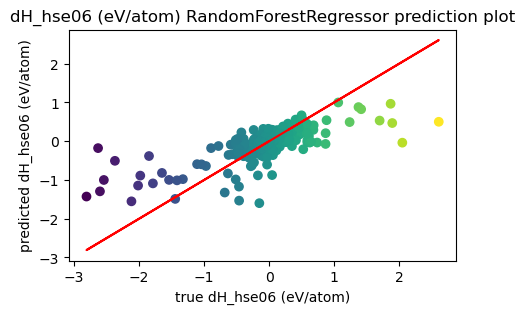

Training scores:
MAE = 0.146
RMSE = 0.294
r^2 = 0.506


In [11]:
rf_1 = joblib.load('rf_dH_hse_df_feat.pkl')
make_prediction_plot(X_test, y1_test, rf_1)

In [12]:
print_cross_val(X, y1, rf_1)

Cross-validation scores:
Mean MAE = 0.131
Mean RMSE = 0.248
Mean r^2 = 0.463


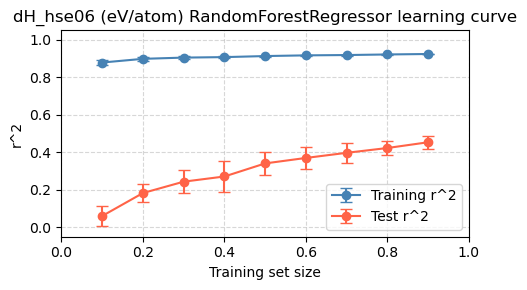

In [13]:
make_learning_curve_plot(X, y1, rf_1)

#### dG

In [14]:
rf_2 = RandomForestRegressor(
    n_estimators=500,
    criterion='squared_error', 
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1,
    max_features=0.8,
    n_jobs=-1
)
rf_2.fit(X_train,y2_train)

# Save
joblib.dump(rf_2, 'rf_dG_hse_df_feat.pkl')

['rf_dG_hse_df_feat.pkl']

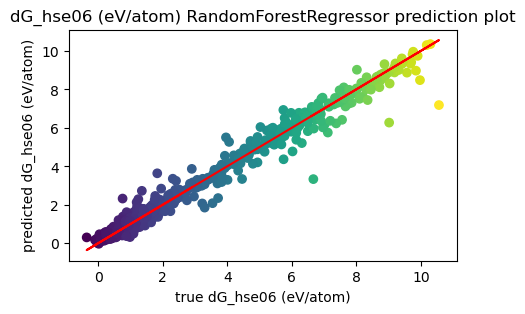

Training scores:
MAE = 0.237
RMSE = 0.408
r^2 = 0.980


In [15]:
rf_2 = joblib.load('rf_dG_hse_df_feat.pkl')
make_prediction_plot(X_test, y2_test, rf_2)

In [16]:
print_cross_val(X, y2, rf_2)

Cross-validation scores:
Mean MAE = 0.232
Mean RMSE = 0.379
Mean r^2 = 0.983


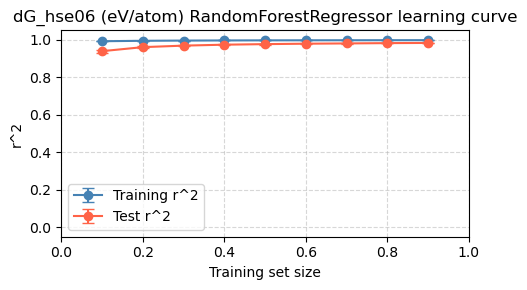

In [17]:
make_learning_curve_plot(X, y2, rf_2)

### Kernel Ridge

#### dH

In [18]:
kr_1 = KernelRidge(
    alpha=0.01,
    gamma=0.01,
    kernel='laplacian',
)
kr_1.fit(X_train,y1_train)

# Save
joblib.dump(kr_1, 'kr_dH_hse_df_feat.pkl')

['kr_dH_hse_df_feat.pkl']

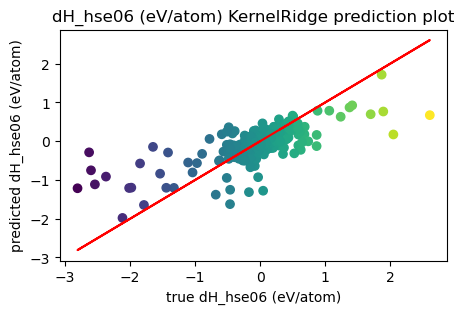

Training scores:
MAE = 0.152
RMSE = 0.297
r^2 = 0.498


In [19]:
kr_1 = joblib.load('kr_dH_hse_df_feat.pkl')
make_prediction_plot(X_test, y1_test, kr_1)

In [20]:
print_cross_val(X, y1, kr_1)

Cross-validation scores:
Mean MAE = 0.146
Mean RMSE = 0.253
Mean r^2 = 0.436


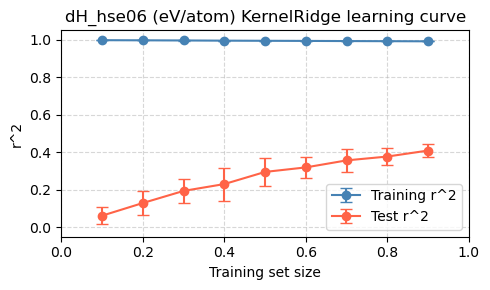

In [21]:
make_learning_curve_plot(X, y1, kr_1)

#### dG

In [22]:
kr_2 = KernelRidge(
    alpha=0.01,
    gamma=0.01,
    kernel='laplacian',
)
kr_2.fit(X_train, y2_train)

# Save
joblib.dump(kr_2, 'kr_dG_hse_df_feat.pkl')

['kr_dG_hse_df_feat.pkl']

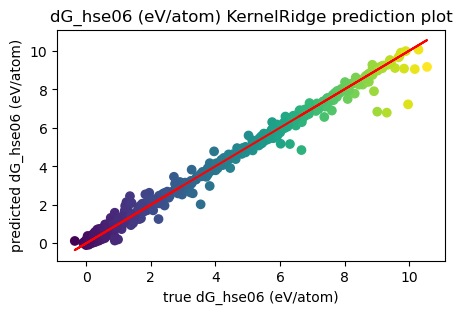

Training scores:
MAE = 0.154
RMSE = 0.292
r^2 = 0.990


In [23]:
kr_2 = joblib.load('kr_dG_hse_df_feat.pkl')
make_prediction_plot(X_test, y2_test, kr_2)

In [24]:
print_cross_val(X, y2, kr_2)

Cross-validation scores:
Mean MAE = 0.145
Mean RMSE = 0.238
Mean r^2 = 0.993


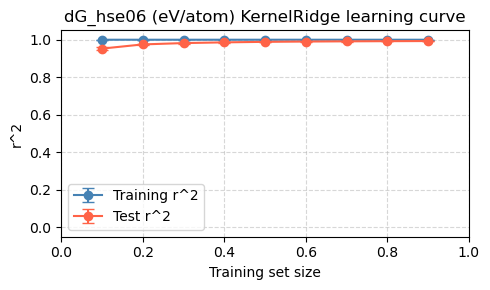

In [25]:
make_learning_curve_plot(X, y2, kr_2)

### XGBoost

#### dH

In [26]:
xgb_1 = XGBRegressor(
    booster='gbtree',
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=3,
    n_estimators=500,
    reg_alpha=1.0,
    reg_lambda=1.0,
    subsample=0.6,
)
xgb_1.fit(X_train,y1_train)

# Save
joblib.dump(xgb_1, 'xgb_dH_hse_df_feat.pkl')

['xgb_dH_hse_df_feat.pkl']

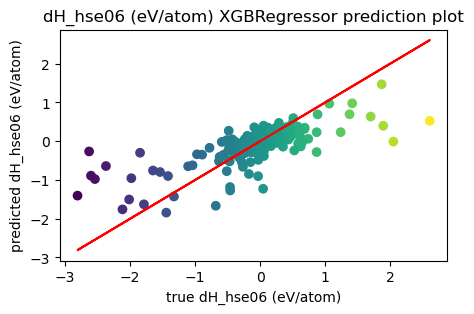

Training scores:
MAE = 0.147
RMSE = 0.293
r^2 = 0.509


In [27]:
xgb_1 = joblib.load('xgb_dH_hse_df_feat.pkl')
make_prediction_plot(X_test, y1_test, xgb_1)

In [28]:
print_cross_val(X, y1, xgb_1)

Cross-validation scores:
Mean MAE = 0.138
Mean RMSE = 0.247
Mean r^2 = 0.466


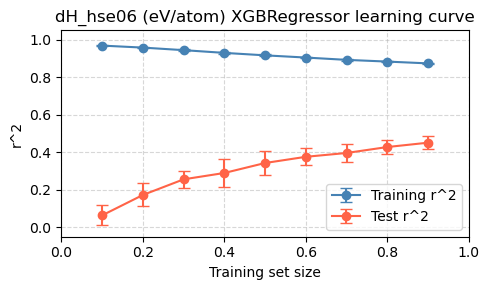

In [29]:
make_learning_curve_plot(X, y1, xgb_1)

#### dG

In [30]:
xgb_2 = XGBRegressor(
    booster='gbtree',
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=3,
    n_estimators=500,
    reg_alpha=1.0,
    reg_lambda=1.0,
    subsample=0.6,
)
xgb_2.fit(X_train,y2_train)

# Save
joblib.dump(xgb_2, 'xgb_dG_hse_df_feat.pkl')

['xgb_dG_hse_df_feat.pkl']

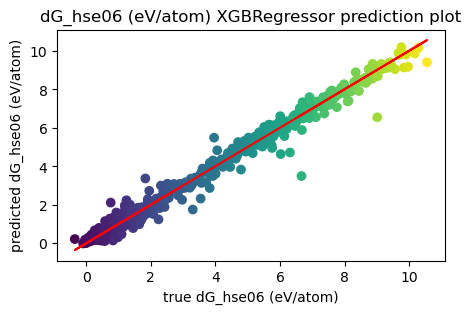

Training scores:
MAE = 0.198
RMSE = 0.327
r^2 = 0.987


In [31]:
xgb_2 = joblib.load('xgb_dG_hse_df_feat.pkl')
make_prediction_plot(X_test, y2_test, xgb_2)

In [32]:
print_cross_val(X, y2, xgb_2)

Cross-validation scores:
Mean MAE = 0.186
Mean RMSE = 0.288
Mean r^2 = 0.990


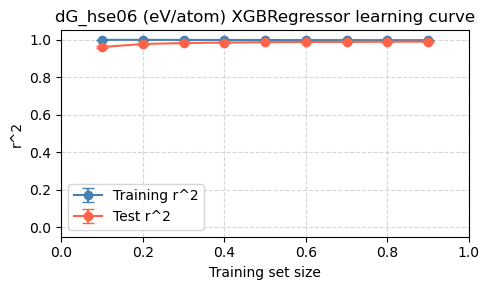

In [33]:
make_learning_curve_plot(X, y2, xgb_2)

### Violins plots

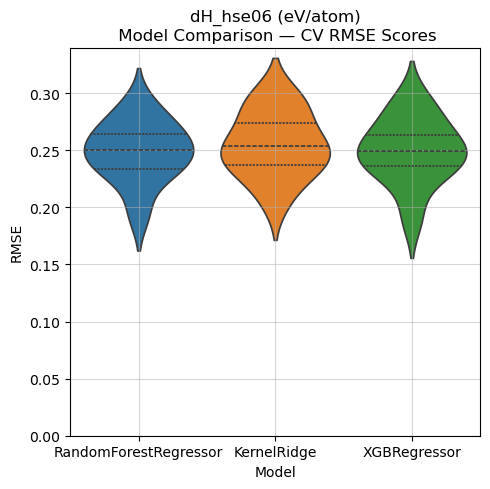

In [34]:
models_1 = [rf_1, kr_1, xgb_1]
make_violin_plot_rmse(X, y1, models_1)

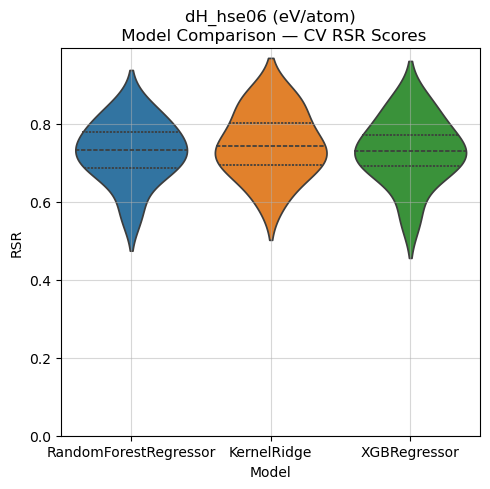

In [35]:
make_violin_plot_rsr(X, y1, models_1)

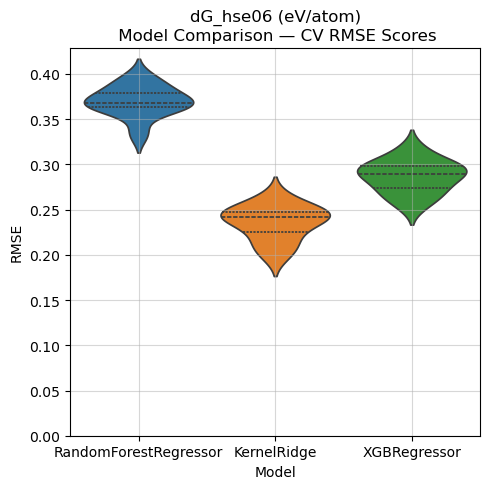

In [36]:
models_2 = [rf_2, kr_2, xgb_2]
make_violin_plot_rmse(X, y2, models_2)

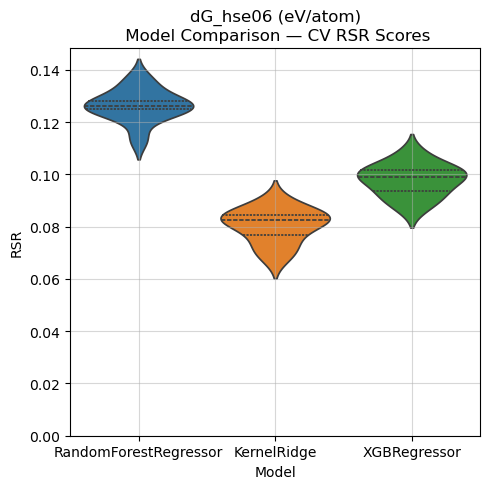

In [37]:
make_violin_plot_rsr(X, y2, models_2)